# Risk budgeting

`RiskBudgeting` takes a different stance from `MeanRisk`. Instead of trading
expected return against risk through an objective function, it allocates *risk itself*: it
finds the portfolio whose per-asset (or per-factor) risk contributions match a user-supplied
budget as closely as possible. There is no objective to maximise — the budget *is* the goal.

The classic special case is the **equal risk contribution (ERC)** portfolio, where every
asset contributes the same share of total risk. Risk budgeting generalises it to any budget
vector, and to risk measured by any of the risk measures `MeanRisk` supports.

> **When to reach for this**
>
> Reach for risk budgeting when you care about *how risk is distributed* rather than about
> a return/risk trade-off — diversifying risk rather than capital, avoiding the
> concentration that minimum-variance portfolios are prone to, or expressing a conviction
> as "this sleeve should carry 30% of the risk". If you instead want the best return for a
> given risk budget, use `MeanRisk`.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use one year of S&P 500 constituents, and (for the factor section) the factor returns.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

ReturnsResult
    nx ┼ 20-element Vector{String}
     X ┼ 252×20 Matrix{Float64}
    nf ┼ nothing
     F ┼ nothing
    nb ┼ nothing
     B ┼ nothing
    ts ┼ 252-element Vector{Date}
    iv ┼ nothing
  ivpa ┴ nothing


Since every optimisation below shares the same data, we precompute the prior statistics once
with `EmpiricalPrior` and reuse them, rather than recomputing them on every call.

In [3]:
using Clarabel
slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
pr = prior(EmpiricalPrior(), rd)
opt = JuMPOptimiser(; pe = pr, slv = slv)

JuMPOptimiser
       pe ┼ LowOrderPrior
          │         X ┼ 252×20 Matrix{Float64}
          │        mu ┼ 20-element Vector{Float64}
          │     sigma ┼ 20×20 Matrix{Float64}
          │      chol ┼ nothing
          │         w ┼ nothing
          │       ens ┼ nothing
          │       kld ┼ nothing
          │        ow ┼ nothing
          │        rr ┼ nothing
          │      f_mu ┼ nothing
          │   f_sigma ┼ nothing
          │       f_w ┴ nothing
      slv ┼ Solver
          │          name ┼ Symbol: :clarabel
          │        solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
          │      settings ┼ Dict{String, Bool}: Dict{String, Bool}("verbose" => 0)
          │     check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
          │   add_bridges ┴ Bool: true
       wb ┼ WeightBounds
          │   lb ┼ Float64: 0.0
          │   ub ┴ Float64: 1.0
      bgt ┼ Float64: 1.0
     sbgt ┼ nothing
       lt ┼ nothi

We budget *variance* risk throughout this example, but any `MeanRisk`-compatible risk
measure works — the risk being budgeted is whatever risk measure you pass.

In [4]:
r = Variance()
N = length(rd.nx)

20

## 2. Asset risk budgeting

`AssetRiskBudgeting` allocates risk across assets. The budget is supplied through the
`rkb` keyword as a `RiskBudget`; the vector does not need to be normalised. The
`alg` keyword selects the formulation — `LogRiskBudgeting` (a log-barrier, the
default) or `MixedIntegerRiskBudgeting` (which needs a mixed-integer solver).

Two budgets: an **equal** budget (the ERC portfolio) and a **linearly increasing** budget
that asks later assets to carry progressively more of the risk.

In [5]:
# Equal risk contribution across assets.
rb_eq = RiskBudgeting(; r = r, opt = opt,
                      rba = AssetRiskBudgeting(; rkb = RiskBudget(; val = fill(1.0, N)),
                                               alg = LogRiskBudgeting()))
# Linearly increasing risk budget across assets.
rb_inc = RiskBudgeting(; r = r, opt = opt,
                       rba = AssetRiskBudgeting(; rkb = RiskBudget(; val = 1:N),
                                                alg = LogRiskBudgeting()))

# Optimise both at once with broadcasting (the prior is precomputed, so no data is needed).
res_eq, res_inc = optimise(rb_eq), optimise(rb_inc)

(RiskBudgetingResult
   jr ┼ JuMPOptimisationResult
      │        oe ┼ DataType: DataType
      │        pa ┼ ProcessedJuMPOptimiserAttributes
      │           │        pr ┼ LowOrderPrior
      │           │           │         X ┼ 252×20 Matrix{Float64}
      │           │           │        mu ┼ 20-element Vector{Float64}
      │           │           │     sigma ┼ 20×20 Matrix{Float64}
      │           │           │      chol ┼ nothing
      │           │           │         w ┼ nothing
      │           │           │       ens ┼ nothing
      │           │           │       kld ┼ nothing
      │           │           │        ow ┼ nothing
      │           │           │        rr ┼ nothing
      │           │           │      f_mu ┼ nothing
      │           │           │   f_sigma ┼ nothing
      │           │           │       f_w ┴ nothing
      │           │        wb ┼ WeightBounds
      │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{F

To verify the budgets were met, we compute the realised risk contributions. The risk measure
must be parametrised with the prior covariance via `factory` before evaluating it.

In [6]:
rf = factory(r, pr)
rc_eq = risk_contribution(rf, res_eq.w, pr.X);
rc_eq ./= sum(rc_eq);
rc_inc = risk_contribution(rf, res_inc.w, pr.X);
rc_inc ./= sum(rc_inc);

pretty_table(DataFrame(; :assets => rd.nx, Symbol("Eq weight") => res_eq.w,
                       Symbol("Eq risk") => rc_eq, Symbol("Incr weight") => res_inc.w,
                       Symbol("Incr risk") => rc_inc); formatters = [resfmt])

┌────────┬───────────┬─────────┬─────────────┬───────────┐
│ assets │ Eq weight │ Eq risk │ Incr weight │ Incr risk │
│ String │   Float64 │ Float64 │     Float64 │   Float64 │
├────────┼───────────┼─────────┼─────────────┼───────────┤
│   AAPL │   3.313 % │   5.0 % │     0.329 % │   0.476 % │
│    AMD │   2.277 % │   5.0 % │     0.483 % │   0.952 % │
│    BAC │    3.98 % │   5.0 % │     1.206 % │   1.429 % │
│    BBY │   3.245 % │   5.0 % │     1.337 % │   1.905 % │
│    CVX │   5.173 % │   5.0 % │     2.313 % │   2.381 % │
│     GE │   3.971 % │   5.0 % │     2.418 % │   2.858 % │
│     HD │   4.182 % │   5.0 % │     2.845 % │   3.333 % │
│    JNJ │   8.221 % │   5.0 % │     5.829 % │    3.81 % │
│    JPM │   4.261 % │   5.0 % │     3.825 % │   4.286 % │
│     KO │   6.254 % │   5.0 % │     5.607 % │   4.761 % │
│    LLY │   5.377 % │   5.0 % │     5.239 % │   5.238 % │
│    MRK │   8.027 % │   5.0 % │     8.242 % │   5.714 % │
│   MSFT │   3.516 % │   5.0 % │     4.483 % │   6.191 %

The equal-budget portfolio puts an identical $1/N$ share of variance on every asset, while
the increasing-budget portfolio"s risk contributions rise monotonically across the assets —
exactly the budgets we asked for.

The risk-contribution bar plot makes the contrast immediate.

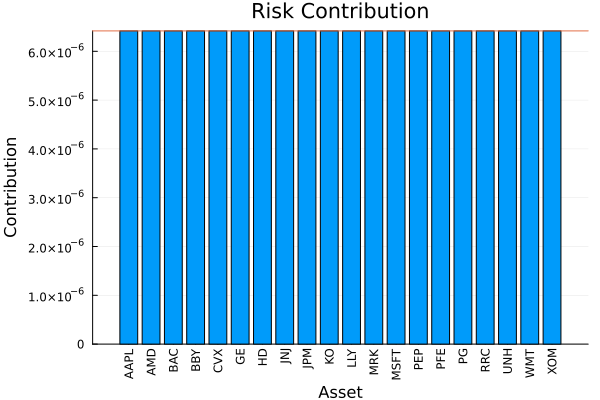

In [7]:
using StatsPlots, GraphRecipes

plot_risk_contribution(rf, res_eq, rd)

And the increasing-budget portfolio:

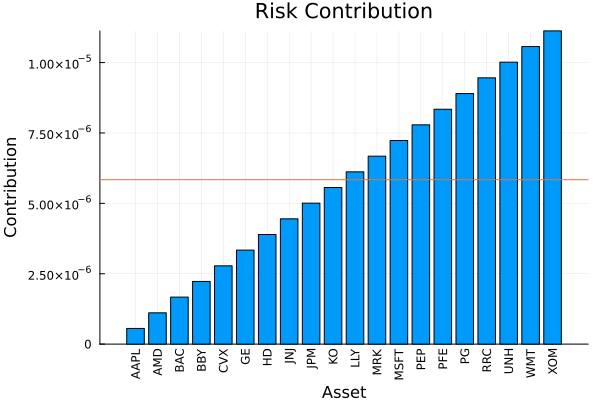

In [8]:
plot_risk_contribution(rf, res_inc, rd)

## 3. Relaxed risk budgeting

`RelaxedRiskBudgeting` (RRB) replaces the non-convex risk-parity constraint with a
second-order-cone relaxation. It needs neither a logarithm nor integer variables, so it is
cheaper to solve — useful at scale. It is variance-specific (the SOC is built on the Cholesky
factor of the covariance), so it takes no `r`. Three variants trade exactness for
regularisation: `BasicRelaxedRiskBudgeting`,
`RegularisedRelaxedRiskBudgeting`, and
`RegularisedPenalisedRelaxedRiskBudgeting`.

Being a *relaxation*, RRB does not adhere to the target risk budget as tightly as the exact
log-barrier or mixed-integer formulations of section 2 — in pathological cases (ill-conditioned
covariance, extreme budgets) the realised contributions can deviate noticeably. In exchange,
the convex SOC formulation composes cleanly with additional constraints, making it the
friendlier choice when the risk budget is one objective among several rather than a hard
requirement. Reach for `RiskBudgeting` when strict adherence is essential.

In [9]:
rba_eq = AssetRiskBudgeting(; rkb = RiskBudget(; val = fill(1.0, N)))
rrb_basic = RelaxedRiskBudgeting(; opt = opt, rba = rba_eq,
                                 alg = BasicRelaxedRiskBudgeting())
rrb_reg = RelaxedRiskBudgeting(; opt = opt, rba = rba_eq,
                               alg = RegularisedRelaxedRiskBudgeting())
res_b, res_r = optimise(rrb_basic), optimise(rrb_reg)

(RiskBudgetingResult
   jr ┼ JuMPOptimisationResult
      │        oe ┼ DataType: DataType
      │        pa ┼ ProcessedJuMPOptimiserAttributes
      │           │        pr ┼ LowOrderPrior
      │           │           │         X ┼ 252×20 Matrix{Float64}
      │           │           │        mu ┼ 20-element Vector{Float64}
      │           │           │     sigma ┼ 20×20 Matrix{Float64}
      │           │           │      chol ┼ nothing
      │           │           │         w ┼ nothing
      │           │           │       ens ┼ nothing
      │           │           │       kld ┼ nothing
      │           │           │        ow ┼ nothing
      │           │           │        rr ┼ nothing
      │           │           │      f_mu ┼ nothing
      │           │           │   f_sigma ┼ nothing
      │           │           │       f_w ┴ nothing
      │           │        wb ┼ WeightBounds
      │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{F

Comparing the relaxed solutions against the exact log-barrier ERC of section 2 shows the
price of the relaxation: on this dataset the relaxed portfolios are noticeably more
concentrated than the exact ERC, so the realised risk contributions spread away from the
flat $1/N$ target. The relaxation buys tractability, not an exact risk-parity solution —
check the realised contributions when you use it.

In [10]:
rc_b = risk_contribution(rf, res_b.w, pr.X);
rc_b ./= sum(rc_b);
rc_r = risk_contribution(rf, res_r.w, pr.X);
rc_r ./= sum(rc_r);

pretty_table(DataFrame(; :assets => rd.nx, Symbol("Log ERC risk") => rc_eq,
                       Symbol("Basic RRB risk") => rc_b,
                       Symbol("Regularised RRB risk") => rc_r); formatters = [resfmt])

┌────────┬──────────────┬────────────────┬──────────────────────┐
│ assets │ Log ERC risk │ Basic RRB risk │ Regularised RRB risk │
│ String │      Float64 │        Float64 │              Float64 │
├────────┼──────────────┼────────────────┼──────────────────────┤
│   AAPL │        5.0 % │        2.965 % │              1.963 % │
│    AMD │        5.0 % │        2.965 % │              1.963 % │
│    BAC │        5.0 % │        2.965 % │              1.963 % │
│    BBY │        5.0 % │        2.965 % │              1.963 % │
│    CVX │        5.0 % │        2.989 % │              4.235 % │
│     GE │        5.0 % │        2.965 % │              1.963 % │
│     HD │        5.0 % │        2.965 % │              1.963 % │
│    JNJ │        5.0 % │       27.581 % │             31.471 % │
│    JPM │        5.0 % │        2.965 % │              1.963 % │
│     KO │        5.0 % │        3.906 % │              7.105 % │
│    LLY │        5.0 % │        2.965 % │              1.963 % │
│    MRK │

## 4. Factor risk budgeting

`FactorRiskBudgeting` allocates risk across *factors* rather than assets, via a
regression of asset returns onto factor returns. It needs the factor returns, so we rebuild
the data with a factor matrix and use a `FactorPrior`.

In [11]:
F = TimeArray(CSV.File(joinpath(@__DIR__, "..", "Factors.csv.gz")); timestamp = :Date)[(end - 252):end]
rdf = prices_to_returns(X, F)
prf = prior(FactorPrior(), rdf)
optf = JuMPOptimiser(; pe = prf, slv = slv)
Nf = length(rdf.nf)

# Equal risk contribution across factors.
frb = RiskBudgeting(; r = Variance(), opt = optf,
                    rba = FactorRiskBudgeting(; rkb = RiskBudget(; val = fill(1.0, Nf))))

RiskBudgeting
  opt ┼ JuMPOptimiser
      │        pe ┼ LowOrderPrior
      │           │         X ┼ 252×20 Matrix{Float64}
      │           │        mu ┼ 20-element Vector{Float64}
      │           │     sigma ┼ 20×20 Matrix{Float64}
      │           │      chol ┼ 25×20 LinearAlgebra.Transpose{Float64, Matrix{Float64}}
      │           │         w ┼ nothing
      │           │       ens ┼ nothing
      │           │       kld ┼ nothing
      │           │        ow ┼ nothing
      │           │        rr ┼ Regression
      │           │           │   M ┼ 20×5 SubArray{Float64, 2, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, UnitRange{Int64}}, true}
      │           │           │   L ┼ 20×5 SubArray{Float64, 2, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, UnitRange{Int64}}, true}
      │           │           │   b ┴ 20-element SubArray{Float64, 1, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, Int64}, true}
      │           │      f_mu ┼ Vector{Float64}

Because `re` here is a regression *estimator* (`StepwiseRegression` by default), the
factor model has to be fit while building the model, so the returns data must be passed to
`optimise` even though the prior is precomputed. (If you instead pass a precomputed
`Regression` *result* as `re`, no data is needed — and a clear error tells you if
you missed passing `rd` when it's required.)

In [12]:
res_frb = optimise(frb, rdf)

RiskBudgetingResult
   jr ┼ JuMPOptimisationResult
      │        oe ┼ DataType: DataType
      │        pa ┼ ProcessedJuMPOptimiserAttributes
      │           │        pr ┼ LowOrderPrior
      │           │           │         X ┼ 252×20 Matrix{Float64}
      │           │           │        mu ┼ 20-element Vector{Float64}
      │           │           │     sigma ┼ 20×20 Matrix{Float64}
      │           │           │      chol ┼ 25×20 LinearAlgebra.Transpose{Float64, Matrix{Float64}}
      │           │           │         w ┼ nothing
      │           │           │       ens ┼ nothing
      │           │           │       kld ┼ nothing
      │           │           │        ow ┼ nothing
      │           │           │        rr ┼ Regression
      │           │           │           │   M ┼ 20×5 SubArray{Float64, 2, Matrix{Float64}, Tuple{Base.Slice{Base.OneTo{Int64}}, UnitRange{Int64}}, true}
      │           │           │           │   L ┼ 20×5 SubArray{Float64, 2, Matrix{Float6

The factor risk contributions (the trailing entry is the intercept/idiosyncratic term)
cluster near the equal $1/N_f$ target across the five factors.

┌───────────┬──────────┐
│    factor │     risk │
│    String │  Float64 │
├───────────┼──────────┤
│      MTUM │ 18.297 % │
│      QUAL │ 19.236 % │
│      SIZE │ 12.766 % │
│      USMV │ 19.457 % │
│      VLUE │ 24.528 % │
│ Intercept │  5.717 % │
└───────────┴──────────┘


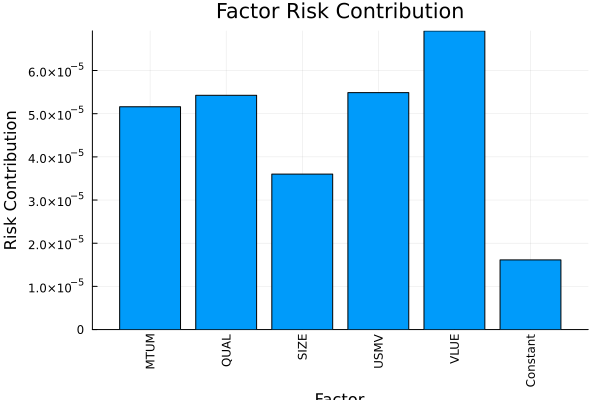

In [13]:
rfk = factory(Variance(), prf)
frc = factor_risk_contribution(rfk, res_frb.w, prf.X; rd = rdf)
frc ./= sum(frc)

pretty_table(DataFrame(; :factor => [rdf.nf; "Intercept"], :risk => frc);
             formatters = [resfmt])

plot_factor_risk_contribution(rfk, res_frb, rdf)

## Summary

Risk budgeting targets a *distribution of risk* rather than a return/risk trade-off:

  - `AssetRiskBudgeting` spreads risk across assets — equal budgets give the ERC
    portfolio, arbitrary budgets express convictions about where risk should sit.
  - `RelaxedRiskBudgeting` is the cheaper convex alternative; verify the realised
    contributions, as the relaxation need not reproduce exact risk parity.
  - `FactorRiskBudgeting` budgets risk across factors instead of assets, at the cost
    of needing the returns data at optimise time.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*